# Homework 3: Databases and a simple geospatial visualisation

**Author:** Your name goes here  
**Date:** 04 March 2026

---

### Contents
1. [DuckDB SQL exercises](#1.-DuckDB-SQL-exercises)
2. [Money in UK Politics](#2.-Money-in-UK-Politics)
3. [Simple geospatial visualisation](#3.-Simple-geospatial-visualisation)


In [ ]:
# Install DuckDB (safe to run even if already installed)
%pip install duckdb --quiet

In [58]:
# ── Load libraries ──────────────────────────────────────────────────────────
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.cm as cm         # colour palettes for visuals
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, TwoSlopeNorm
import seaborn as sns
import duckdb
import geopandas as gpd
from IPython.display import Image, display

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
pd.options.display.float_format = '{:,.0f}'.format

print("Libraries loaded ✓")

Libraries loaded ✓


---
# 1. DuckDB SQL exercises


In [4]:
# ── Connect to an in-memory DuckDB database ──────────────────────────────────
conn = duckdb.connect()

# ── Load the nycflights23 tables into DuckDB ─────────────────────────────────
# This is for all flights out of NYC airports in 2023, not 2013!

flights = pd.read_csv("https://raw.githubusercontent.com/kostis-christodoulou/e628/main/data/nycflights23/flights.csv")
airlines = pd.read_csv("https://raw.githubusercontent.com/kostis-christodoulou/e628/main/data/nycflights23/airlines.csv")
airports = pd.read_csv("https://raw.githubusercontent.com/kostis-christodoulou/e628/main/data/nycflights23/airports.csv")
planes = pd.read_csv("https://raw.githubusercontent.com/kostis-christodoulou/e628/main/data/nycflights23/planes.csv")
weather = pd.read_csv("https://raw.githubusercontent.com/kostis-christodoulou/e628/main/data/nycflights23/weather.csv")


# conn.register() makes each DataFrame available as a SQL table by name.
conn.register('flights',  flights)
conn.register('airlines', airlines)
conn.register('airports', airports)
conn.register('planes',   planes)

print("✅  DuckDB", duckdb.__version__, "connected successfully.")
print("✅  nycflights23 tables registered: flights, airlines, airports, planes")

✅  DuckDB 1.4.4 connected successfully.
✅  nycflights23 tables registered: flights, airlines, airports, planes


---
## The Database: nycflights23

This dataset records every commercial flight that departed one of the three New York City airports (JFK, LGA, EWR) in 2023.

```
airlines                    airports
  │  carrier (PK)             │  faa (PK)
  │  name                     │  name, lat, lon, alt, tz, tzone
  │                           │
  └──< flights >──────────────┘
          │  year, month, day
          │  dep_time, sched_dep_time, dep_delay
          │  arr_time, sched_arr_time, arr_delay
          │  carrier  (FK → airlines)
          │  tailnum  (FK → planes)
          │  origin   (FK → airports.faa)
          │  dest     (FK → airports.faa)
          │  air_time, distance
          │
          └──> planes
                  tailnum (PK)
                  year, type, manufacturer, model
                  engines, seats, engine
```

### Key columns used throughout:
```
dep_delay  = actual departure time − scheduled departure time  (minutes, negative = early)
arr_delay  = actual arrival time   − scheduled arrival time    (minutes, negative = early)
air_time   = total minutes in the air
distance   = distance between origin and destination           (miles)
```


### Explore the Database 

Display the first 10 rows of each table to familiarise yourself with the schema.


In [5]:
sql_query = '''
SELECT *
FROM flights
LIMIT 10;
'''

# one row per flight; the main fact table
df = conn.execute(sql_query).df()
df

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,2023,1,1,1,2038,203,328,3,205,UA,628,N25201,EWR,SMF,367,2500,20,38,2023-01-01T20:00:00Z
1,2023,1,1,18,2300,78,228,135,53,DL,393,N830DN,JFK,ATL,108,760,23,0,2023-01-01T23:00:00Z
2,2023,1,1,31,2344,47,500,426,34,B6,371,N807JB,JFK,BQN,190,1576,23,44,2023-01-01T23:00:00Z
3,2023,1,1,33,2140,173,238,2352,166,B6,1053,N265JB,JFK,CHS,108,636,21,40,2023-01-01T21:00:00Z
4,2023,1,1,36,2048,228,223,2252,211,UA,219,N17730,EWR,DTW,80,488,20,48,2023-01-01T20:00:00Z
5,2023,1,1,503,500,3,808,815,-7,AA,499,N925AN,EWR,MIA,154,1085,5,0,2023-01-01T05:00:00Z
6,2023,1,1,520,510,10,948,949,-1,B6,996,N2043J,JFK,BQN,192,1576,5,10,2023-01-01T05:00:00Z
7,2023,1,1,524,530,-6,645,710,-25,AA,981,N918AN,EWR,ORD,119,719,5,30,2023-01-01T05:00:00Z
8,2023,1,1,537,520,17,926,818,68,UA,206,N13113,EWR,IAH,258,1400,5,20,2023-01-01T05:00:00Z
9,2023,1,1,547,545,2,845,852,-7,NK,225,N912NK,EWR,FLL,157,1065,5,45,2023-01-01T05:00:00Z


In [6]:
sql_query = '''
SELECT *
FROM airlines
LIMIT 10;
'''

# carrier code → full airline name
df = conn.execute(sql_query).df()
df

,carrier,name
0,9E,Endeavor Air Inc.
1,AA,American Airlines Inc.
2,AS,Alaska Airlines Inc.
3,B6,JetBlue Airways
4,DL,Delta Air Lines Inc.
5,F9,Frontier Airlines Inc.
6,G4,Allegiant Air
7,HA,Hawaiian Airlines Inc.
8,MQ,Envoy Air
9,NK,Spirit Air Lines


In [7]:
sql_query = '''
SELECT *
FROM airports
LIMIT 10;
'''

# FAA airport code → name, location, timezone
df = conn.execute(sql_query).df()
df

,faa,name,lat,lon,alt,tz,dst,tzone
0,AAF,Apalachicola Regional Airport,30,-85,20,-5,A,America/New_York
1,AAP,Andrau Airpark,30,-96,79,-6,A,America/Chicago
2,ABE,Lehigh Valley International Airport,41,-75,393,-5,A,America/New_York
3,ABI,Abilene Regional Airport,32,-100,"1,791",-6,A,America/Chicago
4,ABL,Ambler Airport,67,-158,334,-9,A,America/Anchorage
5,ABQ,Albuquerque International Sunport,35,-107,"5,355",-7,A,America/Denver
6,ABR,Aberdeen Regional Airport,45,-98,"1,302",-6,A,America/Chicago
7,ABY,Southwest Georgia Regional Airport,32,-84,197,-5,A,America/New_York
8,ACK,Nantucket Memorial Airport,41,-70,47,-5,A,America/New_York
9,ACT,Waco Regional Airport,32,-97,516,-6,A,America/Chicago


In [8]:
sql_query = '''
SELECT *
FROM planes
LIMIT 10;
'''

# tailnum → aircraft specs
df = conn.execute(sql_query).df()
df

,tailnum,year,type,manufacturer,model,engines,seats,speed,engine
0,N101DQ,"2,020",Fixed wing multi engine,AIRBUS,A321-211,2,199,0,Turbo-fan
1,N101DU,"2,018",Fixed wing multi engine,C SERIES AIRCRAFT LTD PTNRSP,BD-500-1A10,2,133,0,Turbo-fan
2,N101HQ,"2,007",Fixed wing multi engine,EMBRAER-EMPRESA BRASILEIRA DE,ERJ 170-200 LR,2,80,0,Turbo-fan
3,N101NN,"2,013",Fixed wing multi engine,AIRBUS INDUSTRIE,A321-231,2,379,0,Turbo-fan
4,N102DN,"2,020",Fixed wing multi engine,AIRBUS,A321-211,2,199,0,Turbo-fan
5,N102DU,NaN,Fixed wing multi engine,C SERIES AIRCRAFT LTD PTNRSP,BD-500-1A10,2,133,0,Turbo-fan
6,N102HQ,"2,007",Fixed wing multi engine,EMBRAER-EMPRESA BRASILEIRA DE,ERJ 170-200 LR,2,80,0,Turbo-fan
7,N102NN,"2,013",Fixed wing multi engine,AIRBUS,A321-231,2,379,0,Turbo-fan
8,N102UW,"1,998",Fixed wing multi engine,AIRBUS INDUSTRIE,A320-214,2,182,0,Turbo-fan
9,N103DU,NaN,Fixed wing multi engine,C SERIES AIRCRAFT LTD PTNRSP,BD-500-1A10,2,133,0,Turbo-fan


---
## Part A — Single-Table Basics ★☆☆☆


### Task 1 — Filtering Flights

List all flights that departed from **JFK** with a departure delay of **more than 60 minutes**, showing `time_hour`, `flight`, `origin`, `dest`, `dep_delay`, and `carrier`, sorted by the longest delay first.

**Model answer explanation:**
- `WHERE origin = 'JFK'` filters to JFK departures only. `WHERE` filters individual rows before any grouping or aggregation occurs. `HAVING` filters grouped results after aggregation, typically with `GROUP BY`.
- `AND dep_delay > 60` adds the delay condition — both must be true.
- `ORDER BY dep_delay DESC` puts the most delayed flight at the top.


In [ ]:
sql_query = '''


'''

# Execute the query and return results as a DataFrame
df = conn.execute(sql_query).df()

# Expected: 12K+ rows; top row should have dep_delay = 1627 minuts (or roughly 27 hours!)
df

,time_hour,flight,origin,dest,dep_delay,carrier
0,2023-04-20T06:00:00Z,322,JFK,CLT,"1,627",AA
1,2023-04-30T16:00:00Z,840,JFK,CLT,"1,561",AA
2,2023-09-10T11:00:00Z,103,JFK,LAX,"1,369",AA
3,2023-07-18T15:00:00Z,722,JFK,DFW,"1,360",AA
4,2023-09-09T17:00:00Z,1270,JFK,MKE,"1,342",OO
...,...,...,...,...,...,...
12130,2023-06-04T15:00:00Z,855,JFK,ORD,61,AA
12131,2023-06-13T13:00:00Z,1765,JFK,BOS,61,YX
12132,2023-06-01T08:00:00Z,365,JFK,DFW,61,DL
12133,2023-06-04T14:00:00Z,816,JFK,JAX,61,DL


### Task 2 — Flights per Carrier

Count the total number of flights operated by each carrier in 2023, sorted from most to fewest. Show the code and the name of the carrier

**Model answer explanation:**
- `GROUP BY carrier` creates one summary row per unique carrier code.
- `COUNT(*)` counts how many flights each carrier operated.
- `AS num_flights` gives the count column a meaningful name.


In [ ]:
sql_query = '''


'''
# Execute the query and return results as a DataFrame
df = conn.execute(sql_query).df()



df

,carrier,name,num_flights
0,YX,Republic Airline,88785
1,UA,United Air Lines Inc.,79641
2,B6,JetBlue Airways,66169
3,DL,Delta Air Lines Inc.,61562
4,9E,Endeavor Air Inc.,54141
5,AA,American Airlines Inc.,40525
6,NK,Spirit Air Lines,15189
7,WN,Southwest Airlines Co.,12385
8,AS,Alaska Airlines Inc.,7843
9,OO,SkyWest Airlines Inc.,6432


### Task 3 — Time Made Up in the Air

Pilots often make up time during the flight when there is a departure delay.  
Calculate how many minutes each flight **made up** in the air using:

`time_made_up = dep_delay − arr_delay`

A positive value means the flight arrived proportionally less late than it departed (time made up). Show only flights where both delays are not NULL, sorted by the most time made up first.


In [ ]:
sql_query = '''

'''

# Execute the query and return results as a DataFrame
df = conn.execute(sql_query).df()

# Expected top row: a flight that departed 380 min late but arrived only 279 min late (101 min made up)
df

,flight,origin,dest,dep_delay,arr_delay,time_made_up
0,292,LGA,DFW,380,279,101
1,157,JFK,SAN,-3,-96,93
2,242,JFK,SFO,35,-57,92
3,242,JFK,SFO,-1,-92,91
4,157,JFK,SAN,199,109,90
5,114,JFK,SAN,-7,-97,90
6,232,JFK,HNL,137,49,88
7,127,EWR,HNL,62,-23,85
8,336,JFK,SNA,-8,-92,84
9,242,JFK,SFO,2,-82,84


---
## Part B — Multi-Table JOINs ★★☆☆

**JOIN recap:** `JOIN table_b b ON a.fk = b.pk` links rows from two tables where the join columns match.

In SQL, `JOIN` without any keyword defaults to `INNER JOIN`.

Always use table aliases (`f`, `a`, `ap`, `p`) when joining to avoid ambiguous column references.


### Task 4 — Flights with Full Airline Names

Join `flights` and `airlines` to show each flight alongside the full airline name (not just the carrier code), sorted by departure delay descending.

Show `flight`, `airline_name`, `origin`, `dest`, and `dep_delay`. Limit to 20 rows.


In [ ]:
sql_query = '''
 
'''

# Execute the query — joins flights to airlines on carrier code
df = conn.execute(sql_query).df()

# Expected: 20 rows; top row should be American Airlines flight 645, EWR→CLT, 1813 min delay
df

,flight,airline_name,origin,dest,dep_delay
0,645,American Airlines Inc.,EWR,CLT,"1,813"
1,992,American Airlines Inc.,EWR,ORD,"1,781"
2,518,American Airlines Inc.,LGA,DCA,"1,742"
3,600,American Airlines Inc.,LGA,DFW,"1,665"
4,322,American Airlines Inc.,JFK,CLT,"1,627"
5,215,American Airlines Inc.,LGA,CLT,"1,616"
6,840,American Airlines Inc.,JFK,CLT,"1,561"
7,897,American Airlines Inc.,EWR,DFW,"1,557"
8,913,American Airlines Inc.,EWR,ORD,"1,508"
9,455,American Airlines Inc.,EWR,ORD,"1,433"


### Task 5 — Flight Speed

Join `flights` and `airports` to show each flight's destination airport name alongside a calculated speed.

Use the formula:  
`speed_mph = distance / air_time * 60`

Show `flight`, `origin`, `dest_airport` (the full destination name from `airports`), `distance`, `air_time`, and `speed_mph` rounded to 1 decimal place. Exclude rows where `air_time` is NULL. Show the top 20 fastest flights.

**Note:** `airports.faa` is the airport code that matches `flights.dest`.


In [ ]:
sql_query = '''
 
'''

# Execute the query — joins flights to airports on dest = faa
df = conn.execute(sql_query).df()

# Expected top row: LGA -> Chicago Midway, speed_mph should be 806
df

,flight,origin,dest_airport,distance,air_time,speed_mph
0,680,LGA,Chicago Midway International Airport,725,54,806
1,1261,JFK,Charleston Air Force Base-International Airport,636,53,720
2,568,LGA,Miami International Airport,1096,97,678
3,808,EWR,Hartsfield Jackson Atlanta International Airport,746,69,649
4,191,LGA,Hartsfield Jackson Atlanta International Airport,762,73,626
5,965,LGA,Nashville International Airport,764,79,580
6,106,JFK,Miami International Airport,1089,116,563
7,721,JFK,Luis Muñoz Marín International Airport,1598,171,561
8,732,JFK,Luis Muñoz Marín International Airport,1598,171,561
9,158,EWR,Fort Lauderdale Hollywood International Airport,1065,115,556


### Task 6 — Airline Delay Summary

Join `flights` and `airlines` to produce a per-airline summary showing:
- `airline_name` — full name from the `airlines` table
- `total_flights` — total number of flights operated
- `avg_dep_delay` — mean departure delay in minutes (rounded to 2 decimals)
- `avg_arr_delay` — mean arrival delay in minutes (rounded to 2 decimals)
- `avg_distance` - mean distance travelled (rounded to 2 decimals)

Only include flights where both `dep_delay` and `arr_delay` are not NULL.  
Sort by `avg_dep_delay` descending so the most delayed airline appears first.

**JOIN chain:**  
`flights → airlines` (carrier)



In [ ]:
sql_query = '''
 
'''

# Execute the query — two-table JOIN with GROUP BY to summarise delays per airline
df = conn.execute(sql_query).df()

# Expected: 16 rows (one per airline); Frontier Airlines should have the highest avg_dep_delay
df

,airline_name,total_flights,avg_dep_delay,avg_arr_delay,avg_distance
0,Frontier Airlines Inc.,1218,36,26,969
1,JetBlue Airways,64280,24,16,"1,140"
2,Hawaiian Airlines Inc.,362,23,21,"4,983"
3,SkyWest Airlines Inc.,6199,20,14,628
4,Spirit Air Lines,14769,18,10,"1,085"
5,United Air Lines Inc.,77438,17,9,"1,246"
6,Southwest Airlines Co.,12048,16,6,"1,024"
7,Delta Air Lines Inc.,60364,15,2,"1,278"
8,American Airlines Inc.,39750,14,5,"1,156"
9,Alaska Airlines Inc.,7734,12,0,"2,481"


---
# 2. Money in UK Politics

[The Westminster Accounts](https://news.sky.com/story/the-westminster-accounts-12786091) examines the flow of money through UK politics by combining data from three key sources:

1. Register of Members' Financial Interests  
2. Electoral Commission records of donations to parties  
3. Register of All-Party Parliamentary Groups  

Simon Willison extracted the database as an SQLite file — that is what we work with here.


### 2.1 Open a Connection to the Database

In [13]:
# Connect to the SQLite database
conn_westminster = sqlite3.connect("../data/sky-westminster-files.db")

# List all tables in the database
sql_query = '''
SELECT name
FROM sqlite_master
WHERE type = 'table';
'''

df = pd.read_sql_query(sql_query, conn_westminster)
df

,name
0,appg_donations
1,appgs
2,members
3,parties
4,party_donations
5,payments
6,member_appgs


In [14]:
# Load each table into a pandas DataFrame and preview the first 3 rows

sql_query = 'SELECT * FROM appg_donations;'
donations = pd.read_sql_query(sql_query, conn_westminster)

sql_query = 'SELECT * FROM members;'
members = pd.read_sql_query(sql_query, conn_westminster)

sql_query = 'SELECT * FROM parties;'
parties = pd.read_sql_query(sql_query, conn_westminster)

sql_query = 'SELECT * FROM payments;'
payments = pd.read_sql_query(sql_query, conn_westminster)

sql_query = 'SELECT * FROM party_donations;'
party_donations = pd.read_sql_query(sql_query, conn_westminster)

for name, df in [("donations", donations), ("members", members),
                 ("payments", payments), ("party_donations", party_donations),
                 ("parties", parties)]:
    print(f"\n── {name} ({df.shape[0]:,} rows × {df.shape[1]} cols) ──")
    display(df.head(3))


── donations (1,492 rows × 9 cols) ──


,appg_name,category_name,date,description,entity,id,latest_register_entry,paid_for,value
0,'Left Behind' Neighbourhoods,benefits-in-kind,2022-11-07,Secretariat From : 17/06/2022 To : 16/06/2023,Local Trust,3fa80c194b19cbdc9188a956afcd7602,https://publications.parliament.uk/pa/cm/cmall...,,121501
1,'Left Behind' Neighbourhoods,benefits-in-kind,2022-11-07,Report production. Licensing costs. Briefing M...,Local Trust,74cbc9eef62d315a4979f999e97828ad,https://publications.parliament.uk/pa/cm/cmall...,,60001
2,'Left Behind' Neighbourhoods,benefits-in-kind,2021-12-06,"Presentation design. Report writing, design an...",Local Trust,f14b6c505e5122a79579faa8030a9b2b,https://publications.parliament.uk/pa/cm/cmall...,,120001



── members (660 rows × 7 cols) ──


,id,name,gender,constituency,party_id,short_name,status
0,m8,Theresa May,F,Maidenhead,p4,Mrs May,active
1,m1508,Sir Geoffrey Cox,M,Torridge and West Devon,p4,Sir Geoffrey,active
2,m1423,Boris Johnson,M,Uxbridge and South Ruislip,p4,Mr Johnson,active



── payments (10,539 rows × 13 cols) ──


,category,category_name,charity,date,date_visited,description,destination_of_visit,entity,hours,id,member_id,purpose_of_visit,value
0,4. Visits outside the UK,Gifts and other benefits,,Registered in November 2021,Dates of visit: 5-12 November 2021,International flights £805.07; accommodation £...,"Accra, Ghana",GUBA Foundation,,44a5c7f837d9df230b8c1e7f72eea188,m172,To participate in the GUBA Foundation Yaa Asan...,"2,632"
1,2. (b) Any other support not included in Categ...,Cash donations,,Registered in January 2020,,Use of a high street office for the 2019 Gener...,,Mahir Kilic,,b9f40bd69ac24a3507beb70d3408046b,m172,,"2,000"
2,4. Visits outside the UK,Gifts and other benefits,,Registered in September 2022,Dates of visit: 7-12 July 2022,"Flights £1,737.81, accommodation £802.01 and u...","Kingston, Jamaica",People's National Party (PNP) Women's Movement,,54ebb3d5fb5ac528e6534ef5bc89e678,m172,Guest speaker at the PNP Women’s Movement’s 48...,"2,575"



── party_donations (3,430 rows × 6 cols) ──


,date,donation_id,entity,nature_of_donation,party_id,value
0,2020-10-29,C0522788,Aamer A Sarfraz,,p4,"20,000"
1,2020-10-29,C0522787,Aamer A Sarfraz,,p4,"8,000"
2,2020-10-29,C0522863,Aamer A Sarfraz,,p4,"22,000"



── parties (13 rows × 5 cols) ──


,abbrev,background,foreground,id,name
0,Alba,0015ff,,p1034,Alba Party
1,Alliance,C0C0C0,FFFFFF,p1,Alliance
2,Con,0000ff,ffffff,p4,Conservative


### 2.2 Which MP Has Received the Most Money?

You will be working with the `payments` and `members` tables.  
Sum all payments per MP (MP `id` is in `payments`; MP `name` is in `members`), then rank by total.


In [ ]:
sql_query = '''
 
'''

# Use pandas to run the SQL query on the Westminster database connection
df = pd.read_sql_query(sql_query, conn_westminster)

print(f"MP who received the most: {df.iloc[0]['mp_name']}  "
      f"(£{df.iloc[0]['total_payments']:,.0f})")
df

MP who received the most: Theresa May  (£2,809,765)


,member_id,mp_name,party_id,total_payments
0,m8,Theresa May,p4,"2,809,765"
1,m1508,Sir Geoffrey Cox,p4,"2,191,387"
2,m1423,Boris Johnson,p4,"1,282,402"
3,m4514,Keir Starmer,p15,"799,936"
4,m1211,Andrew Mitchell,p4,"769,373"
5,m3958,Fiona Bruce,p4,"712,321"
6,m14,John Redwood,p4,"692,438"
7,m4483,Rishi Sunak,p4,"546,043"
8,m4097,Liz Truss,p4,"538,678"
9,m188,Ed Davey,p17,"441,681"


### 2.3 Any Entity Accounting for More Than 5% of All Donations?

For each entity–MP pair, compute the total donated and express it as a percentage of all payments combined.  
Filter to only those exceeding 5%.


In [ ]:
sql_query = '''
 
'''

# Use pandas to run the SQL query on the Westminster database connection
df = pd.read_sql_query(sql_query, conn_westminster)

print("Entities accounting for > 5% of total payments:")
df

Entities accounting for > 5% of total payments:


,entity,mp_name,party_id,total,percent_of_total
0,Withers LLP,Sir Geoffrey Cox,p4,"1,812,732",5


### 2.4 Do Entity Donors Give to a Single Party or Not?

In [17]:
sql_query = '''
SELECT COUNT(DISTINCT entity) AS distinct_entities
FROM payments;
'''

# Use pandas to run the SQL query on the Westminster database connection
df = pd.read_sql_query(sql_query, conn_westminster)

print(f"Distinct donating entities: {df.iloc[0, 0]:,}")

Distinct donating entities: 2,213


In [ ]:
sql_query = '''

'''

# Use pandas to run the SQL query on the Westminster database connection
df = pd.read_sql_query(sql_query, conn_westminster)

single = (df['donor_type'] == 'Single-party').sum()
multi  = (df['donor_type'] == 'Multi-party').sum()
print(f"Entities donating to a single party only : {single:,}")
print(f"Entities donating to multiple parties    : {multi:,}")
print(f"Single-party % of total                  : {100*single/(single+multi):.1f}%")
df.head(10)

Entities donating to a single party only : 2,036
Entities donating to multiple parties    : 177
Single-party % of total                  : 92.0%


,entity,num_parties,grand_total,donor_type
0,Withers LLP,1,"1,812,732",Single-party
1,Fiona Bruce and Co LLP,1,"711,749",Single-party
2,Charles Stanley,1,"674,821",Single-party
3,Unite,3,"636,313",Multi-party
4,Cambridge Speaker Series,1,"408,200",Single-party
5,GMB Union,2,"397,738",Multi-party
6,MPM Connect,1,"345,217",Single-party
7,Centerview Partners LLP,1,"277,724",Single-party
8,Council of Insurance Agents & Brokers,1,"276,130",Single-party
9,Hindustan Times,1,"261,652",Single-party


In [19]:
# Show only the multi-party donors, largest first
df.query('num_parties > 1').sort_values('grand_total', ascending=False).head(20)

,entity,num_parties,grand_total,donor_type
3,Unite,3,"636,313",Multi-party
5,GMB Union,2,"397,738",Multi-party
10,"Ministry of Foreign Affairs, Qatar",5,"242,373",Multi-party
11,"The Refugee, Asylum and Migration Policy Proje...",4,"239,715",Multi-party
29,The Carlton Club,2,"156,570",Multi-party
36,IX Wireless,2,"138,801",Multi-party
48,Birmingham City Council,2,"118,995",Multi-party
53,Conservative Friends of Israel (CFI),2,"116,723",Multi-party
54,GB News,2,"115,952",Multi-party
55,Community Union,2,"115,009",Multi-party


### 2.5 Which Party Raised the Most in Each of 2020–2022?

You will work with the `party_donations` and `parties` table.

Since the party_donations has a `date` column, you will need to extract the year from the date column.

`strftime('%Y', date) AS year` will extract the year from the date column.



In [ ]:
sql_query = '''
SELECT
    strftime('%Y', pd.date) AS year,

'''

# Use pandas to run the SQL query on the Westminster database connection
df = pd.read_sql_query(sql_query, conn_westminster)

df

# Pivot for readability: rows = parties, columns = years
pivot = (df.pivot_table(
    index="party_name", 
    columns="year",
    values="total_donations", 
    aggfunc="sum"
)
.fillna(0)
# .reset_index()
.sort_values(by='2022', ascending=False)
)

pivot

year,2020,2021,2022
party_name,,,
Conservative,"42,770,782","17,718,212","15,568,476"
Labour,"13,539,803","9,493,978","9,460,879"
Liberal Democrats,"12,717,295","700,398","1,727,152"
Green Party,"378,068","217,375","329,474"
Sinn Féin,"113,892","822,944","229,640"
Scottish National Party,"246,284","654,678","222,230"
Alliance,"105,000","42,500","180,600"
Alba Party,0,"53,559","50,000"
Plaid Cymru,"70,000","122,300","49,641"


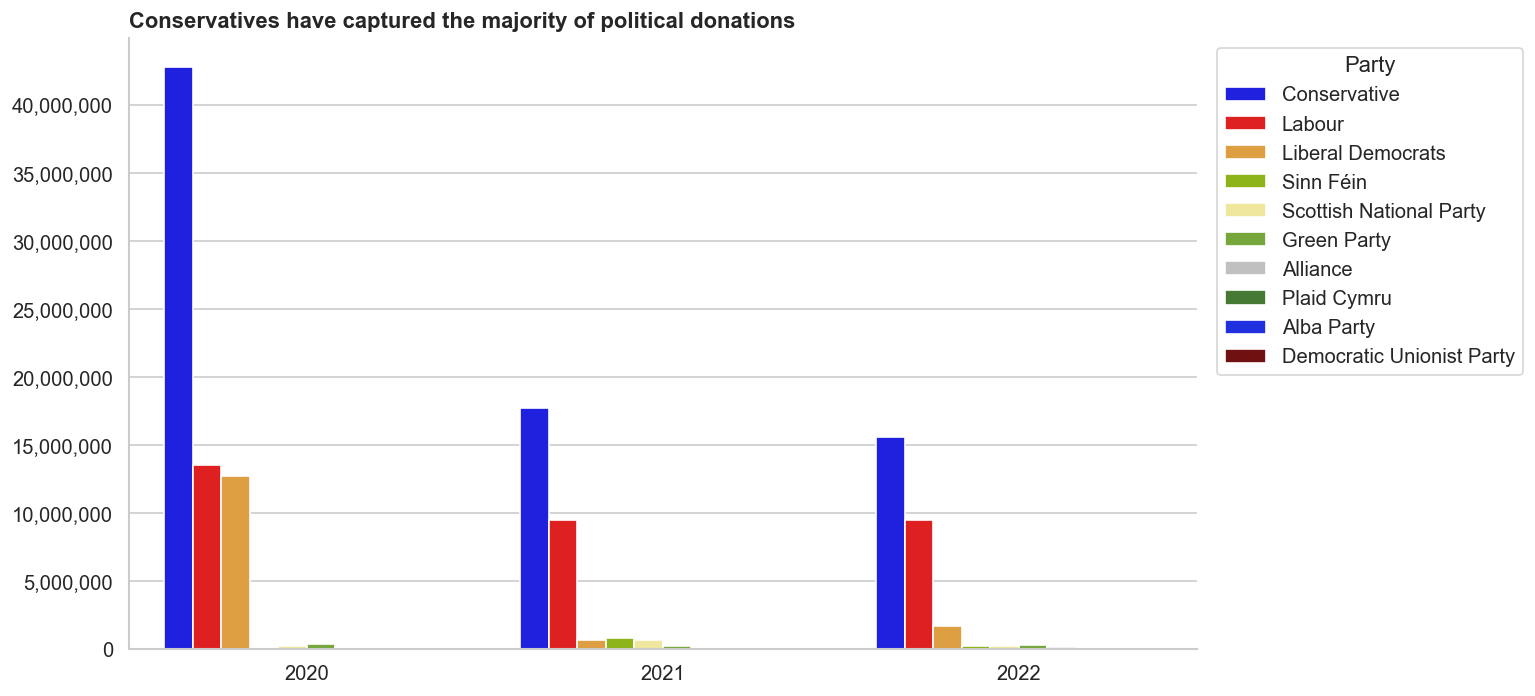

In [41]:
# Plot — donations by party per year (dodged bar chart)
parties_df = pd.read_sql_query("SELECT * FROM parties;", conn_westminster)
party_palette = {row["name"]: f"#{row['background']}" for _, row in parties_df.iterrows()}
party_palette["Democratic Unionist Party"] = "#800000"
del party_palette["Speaker"]

party_order = (
    df.groupby("party_name")["total_donations"].sum()
    .sort_values(ascending=False)
    .index.tolist()
)

plot_df = df.copy()
plot_df["year"] = plot_df["year"].astype(int).astype(str)

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(
    data=plot_df,
    x="year", y="total_donations",
    hue="party_name",
    hue_order=party_order,
    palette=party_palette,
    ax=ax
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_title("Conservatives have captured the majority of political donations",
             loc="left", fontweight="bold")
ax.set_xlabel(None)
ax.set_ylabel(None)
ax.legend(title="Party", bbox_to_anchor=(1.01, 1), loc="upper left")
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# Close the database connection
conn_westminster.close()
print("Database connection closed.")

---
# 3. Simple geospatial visualisation

Try to recreate the county-level margins for the 2024 US Presidential election.  
No need to make it look exactly like the reference image shown below — how you approach it is up to you.  
The background map was created using the shapefile from https://urbaninstitute.github.io/urbnmapr/


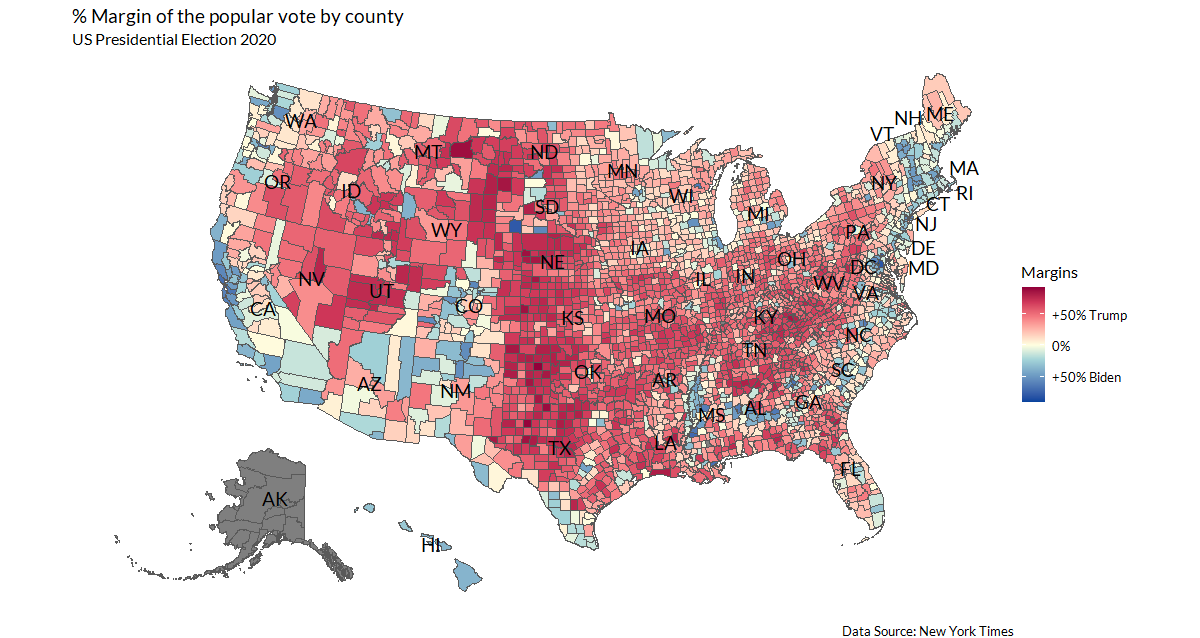

In [23]:
filename = 'geospatial.png'
display(Image(filename))

In [43]:
# Load the 2024 US county-level Presidential results
us_elections_2024 = pd.read_csv('../data/2024_US_County_level_Presidential_Results.csv')

# Zero-pad and compute margin (%)


# .astype(str) — ensures the result is a string type, in case either column was stored as integers
# .str.zfill(5) — zero-pads the result to ensure it's always 5 characters long (e.g., if somehow the combined value came out as "637", it would become "00637")

us_elections_2024["county_fips"] = us_elections_2024["county_fips"].astype(str).str.zfill(5)
us_elections_2024["margin_gop"] = (us_elections_2024["per_gop"] - us_elections_2024["per_dem"]) * 100

us_elections_2024.head()

,state_name,county_fips,county_name,votes_gop,votes_dem,total_votes,diff,per_gop,per_dem,per_point_diff,margin_gop
0,Alabama,01001,Autauga County,20484,7439,28190,"13,045",1,0,0,46
1,Alabama,01003,Baldwin County,95798,24934,121808,"70,864",1,0,1,58
2,Alabama,01005,Barbour County,5606,4158,9832,"1,448",1,0,0,15
3,Alabama,01007,Bibb County,7572,1619,9241,"5,953",1,0,1,64
4,Alabama,01009,Blount County,25354,2576,28115,"22,778",1,0,1,81


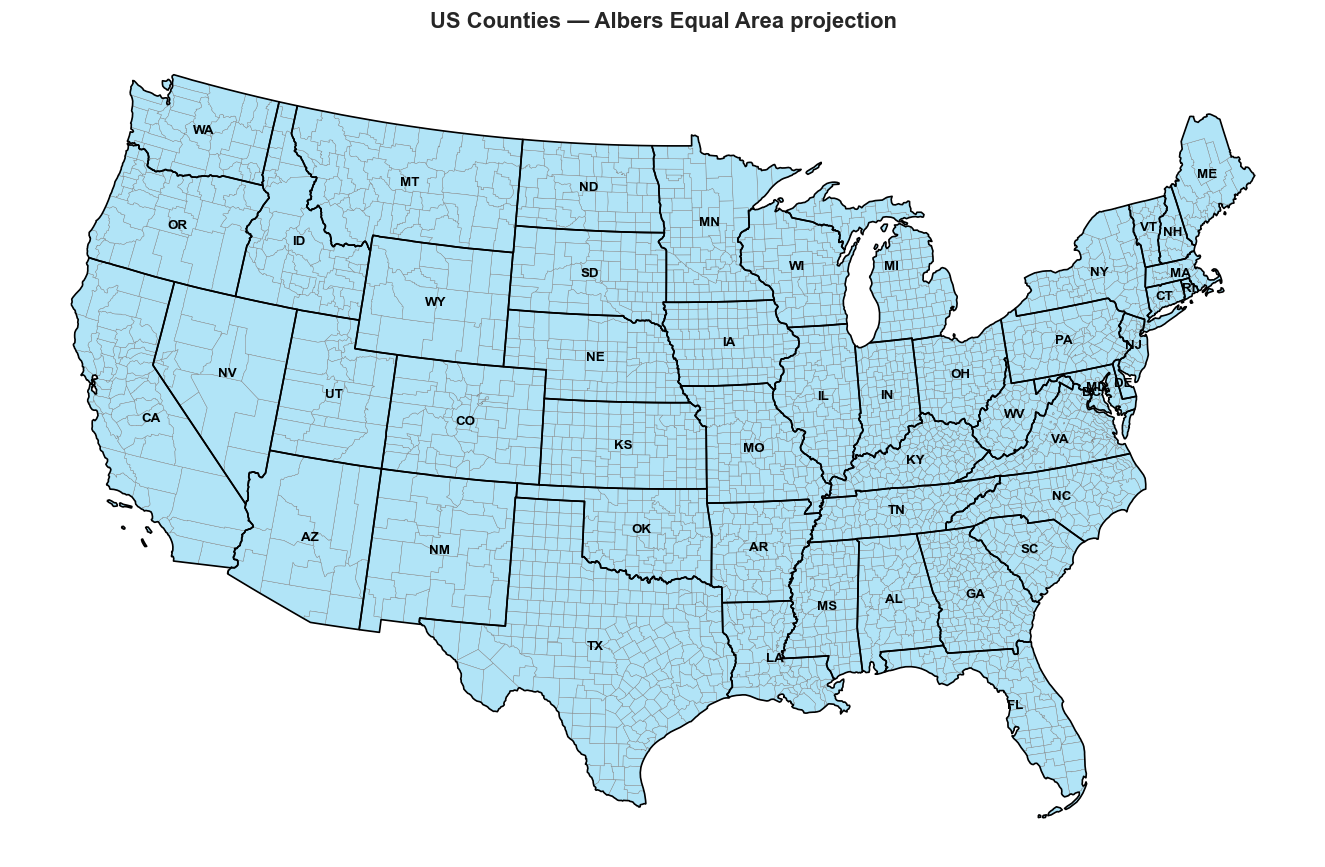

In [65]:
# Download the US counties shapefile directly from the Census Bureau
url = "https://www2.census.gov/geo/tiger/GENZ2024/shp/cb_2024_us_county_20m.zip"

# Read shapefile directly from the ZIP URL using GeoPandas
counties_gdf = gpd.read_file(url)

# Filter out Alaska (02), Hawaii (15), and Puerto Rico (72) for a clean contiguous-US map
counties_gdf = counties_gdf[~counties_gdf['STATEFP'].isin(['02', '15', '72'])]

# Reproject to Albers Equal Area (contiguous USA)
counties_gdf = counties_gdf.to_crs('ESRI:102003')

# Create 5-digit FIPS - this should be the same as GEOID, but we make sure we fill in with 0 any FIPS thsat are < 5 digits long

# counties_gdf["STATEFP"] + counties_gdf["COUNTYFP"] — concatenates the two columns as strings (e.g., "06" + "037" = "06037")
# .astype(str) — ensures the result is a string type, in case either column was stored as integers
# .str.zfill(5) — zero-pads the result to ensure it's always 5 characters long (e.g., if somehow the combined value came out as "637", it would become "00637")

counties_gdf["county_fips"] = (counties_gdf["STATEFP"] + counties_gdf["COUNTYFP"]).astype(str).str.zfill(5)

# -------------------------------------------------------
# STEP  Create state-level borders
# -------------------------------------------------------
# counties_gdf has a column 'STATEFP' (state FIPS code).
# .dissolve() merges all county shapes within each state into one big shape.
# .boundary then extracts just the outline (the border line, not the filled shape).
# We'll overlay this on the map later so state lines appear darker than county lines.

state_borders = counties_gdf.dissolve(by="STATEFP").boundary


fig, ax = plt.subplots(figsize=(14, 9))  # create a blank canvas (width=14, height=9 inches)


# Preview the base map

counties_gdf.plot(
    linewidth=0.25,
    edgecolor="grey",
    ax=ax,
    color = "#b1e4f7"
)

# Draw state borders on top — thicker and black so states stand out clearly
state_borders.plot(ax=ax, color="black", linewidth=1)

# -------------------------------------------------------
# STEP 6: Add state abbreviations at each state's center
# -------------------------------------------------------

# You'll need a mapping of STATEFP (2-digit FIPS code) → state abbreviation.
# STATEFP is the ID already present in your shapefile.
fips_to_abbrev = {
    '01': 'AL', '02': 'AK', '04': 'AZ', '05': 'AR', '06': 'CA',
    '08': 'CO', '09': 'CT', '10': 'DE', '11': 'DC', '12': 'FL',
    '13': 'GA', '15': 'HI', '16': 'ID', '17': 'IL', '18': 'IN',
    '19': 'IA', '20': 'KS', '21': 'KY', '22': 'LA', '23': 'ME',
    '24': 'MD', '25': 'MA', '26': 'MI', '27': 'MN', '28': 'MS',
    '29': 'MO', '30': 'MT', '31': 'NE', '32': 'NV', '33': 'NH',
    '34': 'NJ', '35': 'NM', '36': 'NY', '37': 'NC', '38': 'ND',
    '39': 'OH', '40': 'OK', '41': 'OR', '42': 'PA', '44': 'RI',
    '45': 'SC', '46': 'SD', '47': 'TN', '48': 'TX', '49': 'UT',
    '50': 'VT', '51': 'VA', '53': 'WA', '54': 'WV', '55': 'WI',
    '56': 'WY',
}

# Dissolve counties into states (you already did this for borders above,
# but here we keep it as polygons — not just the boundary — so we can get centroids)
states_gdf = counties_gdf.dissolve(by="STATEFP")

# .centroid gives the geometric center point of each state polygon.
# We then extract the x (longitude) and y (latitude) from that point.
states_gdf["centroid"] = states_gdf.geometry.centroid
states_gdf["x"] = states_gdf["centroid"].x
states_gdf["y"] = states_gdf["centroid"].y

# Map the FIPS code (the index after dissolve) to the abbreviation
states_gdf["abbrev"] = states_gdf.index.map(fips_to_abbrev)

# Loop through each state and place its abbreviation text at the centroid
for _, row in states_gdf.iterrows():
    if pd.isna(row["abbrev"]):
        continue  # skip if FIPS code wasn't in our dictionary

    ax.text(
        row["x"], row["y"],         # position: centroid of the state
        row["abbrev"],              # the text to display e.g. "PA"
        fontsize=8,                 # small so it fits inside smaller states
        ha="center", va="center",  # centre the text on the point
        color="black",
        fontweight="bold",
    )


plt.title("US Counties — Albers Equal Area projection", fontweight="bold")
plt.axis("off")
plt.show()

# Colour scale used in — blue (Democrat) → white → red (Republican)
my_scale = ['#00429d', '#4771b2', '#73a2c6', '#a5d5d8', '#ffffe0',
            '#ffbcaf', '#f4777f', '#cf3759', '#93003a']

In [34]:

counties_gdf.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOIDFQ,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,geometry,county_fips
0,18,087,00450368,0500000US18087,18087,LaGrange,LaGrange County,IN,Indiana,06,983242853,18311996,"POLYGON ((851901.105 523582.088, 882051.602 52...",18087
1,20,107,00485018,0500000US20107,20107,Linn,Linn County,KS,Kansas,06,1538662703,31893232,"POLYGON ((80824.305 100142.759, 120022.594 100...",20107
2,24,029,00593907,0500000US24029,24029,Kent,Kent County,MD,Maryland,06,717268761,353549972,"POLYGON ((1676654.007 359059.492, 1678053.142 ...",24029
3,31,065,00835854,0500000US31065,31065,Furnas,Furnas County,NE,Nebraska,06,1862730830,3727356,"POLYGON ((-353382.291 327213.13, -344710.283 3...",31065
4,13,237,00347246,0500000US13237,13237,Putnam,Putnam County,GA,Georgia,06,892721735,41451860,"POLYGON ((1148068.266 -379579.813, 1170574.087...",13237


Merge success rate: 1.0


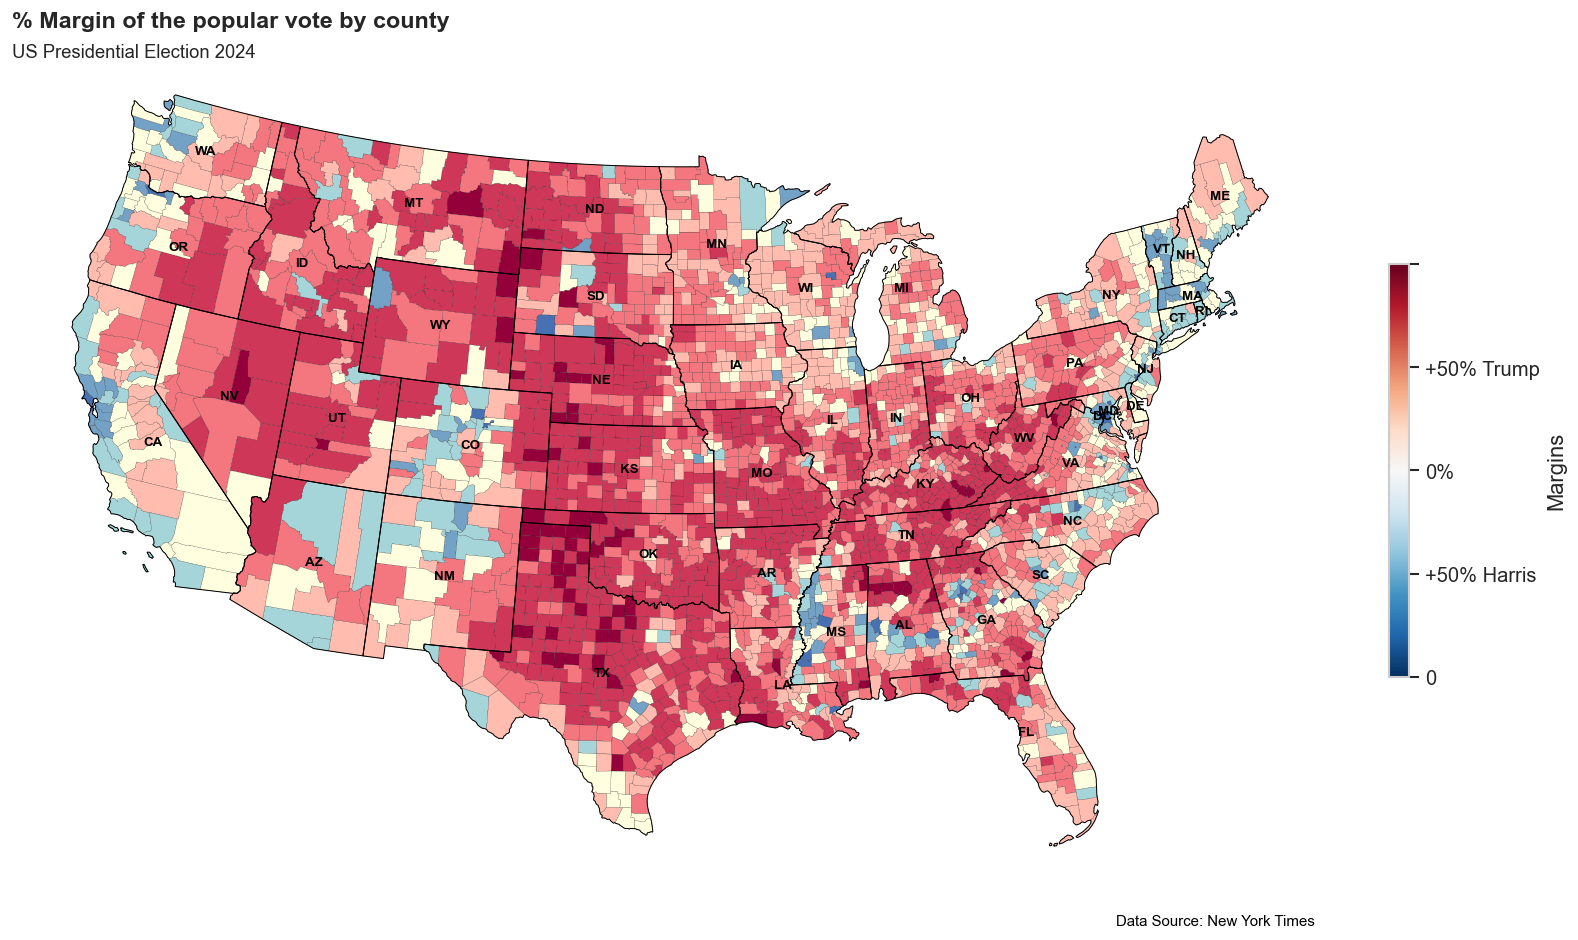

In [70]:
# Plot map 
fig, ax = plt.subplots(1, 1, figsize=(14, 8))

# -------------------------------------------------------
# STEP 1: Merge the shapefile with election results
# -------------------------------------------------------
# We have two tables:
#   - counties_gdf: a GeoDataFrame with county shapes + a 'county_fips' ID column
#   - us_elections_2024: a regular DataFrame with vote margins + a 'county_fips' ID column
#
# .merge() joins them side-by-side wherever 'county_fips' matches — like a SQL JOIN.
# validate="1:1" is a safety check: it throws an error if any county appears more than once.

map2024 = counties_gdf.merge(
    us_elections_2024[["county_fips", "state_name", "county_name", "margin_gop"]],
    on="county_fips",       # the shared key column to match rows on
    validate="1:1"          # enforce a strict one-to-one match (no duplicates)
)

# Quick sanity check: what fraction of counties successfully got election data?
# isna().mean() gives the share of missing values; subtracting from 1 gives the hit rate.
print("Merge success rate:", 1 - map2024["margin_gop"].isna().mean())


# -------------------------------------------------------
# STEP 2: Create state-level borders and abbreviations
# -------------------------------------------------------
# counties_gdf has a column 'STATEFP' (state FIPS code).
# .dissolve() merges all county shapes within each state into one big shape.
# .boundary then extracts just the outline (the border line, not the filled shape).
# We'll overlay this on the map later so state lines appear darker than county lines.

state_borders = counties_gdf.dissolve(by="STATEFP").boundary

# -------------------------------------------------------
# STEP 3: Define the colour scale
# -------------------------------------------------------
# margin_gop = (GOP% - Dem%) at the county level
#   Negative values → Democrat-leaning  → we want blue
#   Zero             → perfectly split   → we want white/light yellow
#   Positive values  → Republican-lean   → we want red
#
# The list below defines 9 colour "anchor" points from deep blue → white → deep red.
# LinearSegmentedColormap smoothly interpolates between them across 256 colour steps.

my_scale = [
    '#00429d',  # deep blue   (strong Democrat)
    '#4771b2',
    '#73a2c6',
    '#a5d5d8',
    '#ffffe0',  # pale yellow (near-even split)
    '#ffbcaf',
    '#f4777f',
    '#cf3759',
    '#93003a',  # deep red    (strong Republican)
]


# define colour scale
nyt_cmap = ListedColormap(my_scale)
norm = TwoSlopeNorm(vmin=-100, vcenter=0, vmax=100)

# Fill Counties by vote margin
map2024.plot(
    ax=ax,
    column="margin_gop",
    cmap=nyt_cmap,
    norm=norm,
    linewidth=0.1,
    edgecolor="black"
)

# Draw state borders on top — thicker and black so states stand out clearly
state_borders.plot(ax=ax, color="black", linewidth=0.6)

# Add state abbreviations at each state's center
# You'll need a mapping of STATEFP (2-digit FIPS code) → state abbreviation.
# STATEFP is the ID already present in your shapefile.
fips_to_abbrev = {
    '01': 'AL', '02': 'AK', '04': 'AZ', '05': 'AR', '06': 'CA',
    '08': 'CO', '09': 'CT', '10': 'DE', '11': 'DC', '12': 'FL',
    '13': 'GA', '15': 'HI', '16': 'ID', '17': 'IL', '18': 'IN',
    '19': 'IA', '20': 'KS', '21': 'KY', '22': 'LA', '23': 'ME',
    '24': 'MD', '25': 'MA', '26': 'MI', '27': 'MN', '28': 'MS',
    '29': 'MO', '30': 'MT', '31': 'NE', '32': 'NV', '33': 'NH',
    '34': 'NJ', '35': 'NM', '36': 'NY', '37': 'NC', '38': 'ND',
    '39': 'OH', '40': 'OK', '41': 'OR', '42': 'PA', '44': 'RI',
    '45': 'SC', '46': 'SD', '47': 'TN', '48': 'TX', '49': 'UT',
    '50': 'VT', '51': 'VA', '53': 'WA', '54': 'WV', '55': 'WI',
    '56': 'WY',
}

# Dissolve counties into states (you already did this for borders above,
# but here we keep it as polygons — not just the boundary — so we can get centroids)
states_gdf = counties_gdf.dissolve(by="STATEFP")

# .centroid gives the geometric center point of each state polygon.
# We then extract the x (longitude) and y (latitude) from that point.
states_gdf["centroid"] = states_gdf.geometry.centroid
states_gdf["x"] = states_gdf["centroid"].x
states_gdf["y"] = states_gdf["centroid"].y

# Map the FIPS code (the index after dissolve) to the abbreviation
states_gdf["abbrev"] = states_gdf.index.map(fips_to_abbrev)

# Loop through each state and place its abbreviation text at the centroid
for _, row in states_gdf.iterrows():
    if pd.isna(row["abbrev"]):
        continue  # skip if FIPS code wasn't in our dictionary

    ax.text(
        row["x"], row["y"],         # position: centroid of the state
        row["abbrev"],              # the text to display e.g. "PA"
        fontsize=8,                 # small so it fits inside smaller states
        ha="center", va="center",  # centre the text on the point
        color="black",
        fontweight="bold",
    )


# titles
ax.set_title("% Margin of the popular vote by county", fontsize=14, fontweight="bold", loc="left")
ax.text(0, 1, "US Presidential Election 2024", transform=ax.transAxes, fontsize=11, ha="left")

# colour bar
cmap = plt.get_cmap('RdBu_r')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.04, pad=0.04, shrink=0.5)
cbar.set_label('Margins'); cbar.set_ticks([-100,-50,0,50,100])
cbar.set_ticklabels(["0","+50% Harris","0%","+50% Trump", ""])


# souce
ax.text(
    0.99, -0.05,
    "Data Source: New York Times",
    transform=ax.transAxes,
    fontsize=9,
    color="black",
    ha="right"
)

ax.axis("off")
plt.tight_layout()
plt.show()

# Build an interactive dashboard

We have seen a number of datasets and so far you have analysed and plotted a few things related to 

1. avocado sales in the United States
2. Domestic flights out of the three NYC airports in 2013 and 2023
3. UK donations to members of parliament and political parties
4. financial data, with prices and risk-return for a number of stocks, as well as yield curve and its inversion


I have created an avocado dashboard on https://avocado-dashboard.onrender.com/ and want you to pick anyting you want and create such a dashboard yourself.

Your dashboard should be interactive and allow the user to explore the data in a meaningful way.

You can take your solutions to anything you worked on, and upload it either on claude code or on aistudio.google.com with a prompt like the onw below, if you worked on an avocado dashboard:

"""
I have a dataset of avocado sales in the United States (avocado.csv) and an existing analysis 
notebook (attached .ipynb). I want to convert my analysis into an interactive Dash dashboard.

REQUIREMENTS:
- Language/Libraries: Python, pandas (keep all existing analysis logic unchanged), 
  Plotly (replace all visualisations), and Dash (for the dashboard framework)
- Do NOT use TypeScript or modify any existing analytical logic — only change how results are visualised

BEFORE writing any code:
1. Review my .ipynb file thoroughly
2. Draft an action_plan.md that outlines:
   - Each section/page of the dashboard and its purpose
   - Which existing plots will be converted and how
   - Any new interactive elements (dropdowns, sliders, filters) you plan to add and why
   - The file/component structure you'll use
3. Save the plan as action_plan.md and STOP — wait for my approval before writing any code

Only proceed with building after I explicitly confirm the plan.
"""


You can also setup a free account on render.com and deploy your dashboard there, especially after pushing it to github.com